
### Fraud detection Dataset taken from kaggle's website

To get more information on the data, refer to: https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset/data

Little annotations to consider in the dataset.

1. All frauds are tye "CASH_OUT" and "TRANSFER". Get rid of all the other trasnactions in the dataset

2. While making trasnfer, the old balance cannot be 0. Anomaly

3. FInal amount and initial amount must differ by transaction amount

4. Same applies for a sender

5. Create a new Column which have the error value of (transfer) - (mod(sendamt - rec amt))

In [ ]:
%pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier
import seaborn as sns
import pickle
# for plotting graph in jupyter cell
%matplotlib inline

print(pd.__version__)
print(np.__version__)

3.0.2
2.4.4


In [ ]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style = "whitegrid")

In [3]:
df = pd.read_csv("AIML Dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [8]:
len(df)

6362620

In [4]:
# Theory dismounted that refered to shell accounts being used to pass data

df_fraud = df[df["isFraud"] == 1]
set1 = set(df_fraud["nameOrig"].values.tolist()) 
set2 = set(df_fraud["nameDest"].values.tolist())
l = set1.intersection(set2)
l

set()

## Preprocessing of Data

In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
# Knowing if there are any nulls on the df
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Now we create 4 lists of the gven data namely:

L1) The hour when the fraud happened

L2) ttoal transactions then

L3) Fraud transactions

L4) Valid transactions

In [ ]:
def fraud_per_hour(df):

    l1,l2,l3,l4 = [], [], [], []

    for h in df["step"].unique():
        t_df = df.loc[df["step"] == h]
        l1.append(h)                                        # Every hour
        l2.append(t_df.shape[0])                            # total transactions per hour
        l3.append(t_df.loc[t_df["isFraud"] == 1].shape[0])  # Every hour where there is fraud
        l4.append(t_df.loc[t_df["isFraud"] == 0].shape[0])  # Every hour where there isn't fraud

    return (l1,l2,l3,l4)
    
# Getting generated list of Data
l1, l2, l3, l4 = fraud_per_hour(df)

# reate a new DataFrame
fraud_tx_per_hour = pd.DataFrame()

# Add new olumns to the DataFrame
fraud_tx_per_hour["hour"] = l1
fraud_tx_per_hour["total_tx"] = l2
fraud_tx_per_hour["fraud_tx"] = l3
fraud_tx_per_hour["valid_tx"] = l4
fraud_tx_per_hour

,hour,total_tx,fraud_tx,valid_tx
0,1,2708,16,2692
1,2,1014,8,1006
2,3,552,4,548
3,4,565,10,555
4,5,665,6,659
...,...,...,...,...
738,739,10,10,0
739,740,6,6,0
740,741,22,22,0
741,742,14,14,0


In [ ]:
plt.figure(figsize=(12, 150))
sns.barplot(y = "hour", x = "fraud_tx", orient = "h",data = fraud_tx_per_hour)

In [24]:
fraud_tx_per_hour["fraud_tx"].describe()

count    743.000000
mean      11.053836
std        4.998631
min        0.000000
25%        8.000000
50%       10.000000
75%       14.000000
max       40.000000
Name: fraud_tx, dtype: float64

### **Visualization Insights**

- Fraud are low corelated to time

- CASH_OUT outweighs the number of TRANSFER in normal transactions

- In fraudulent transactions the number of CASH_OUT and Transfer is same.

- error in transaction(new col) is best parameter

### **Plot the data from above**

Text(0, 0.5, 'Number of transactions')

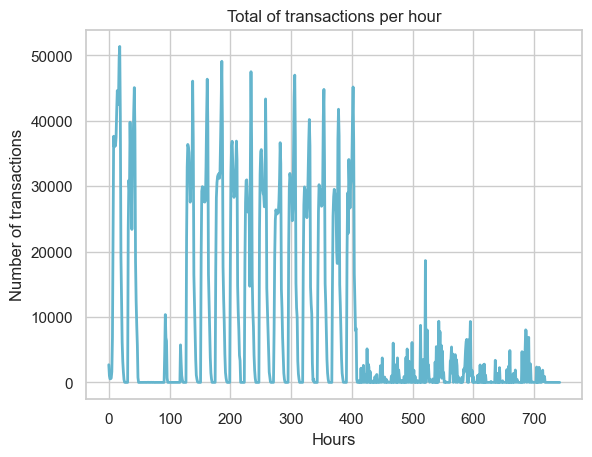

In [16]:
plt.plot(l2, color = "c", linewidth = 2)
plt.title("Total of transactions per hour")
plt.xlabel("Hours")
plt.ylabel("Number of transactions")

Text(0, 0.5, 'Fraudulent transactions')

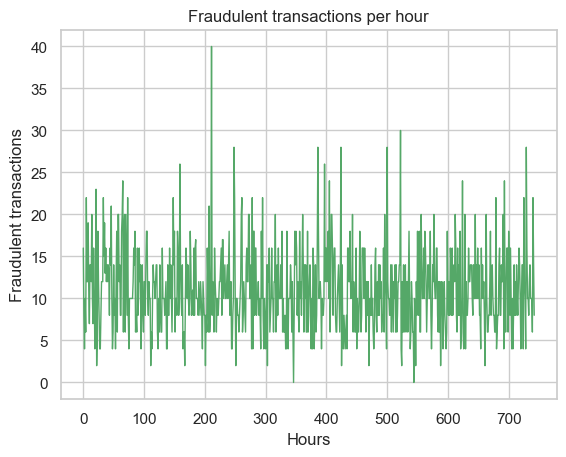

In [17]:
plt.plot(l3, color = "g", linewidth = 1)
plt.title("Fraudulent transactions per hour")
plt.xlabel("Hours")
plt.ylabel("Fraudulent transactions")

Text(0, 0.5, 'Normal transactions')

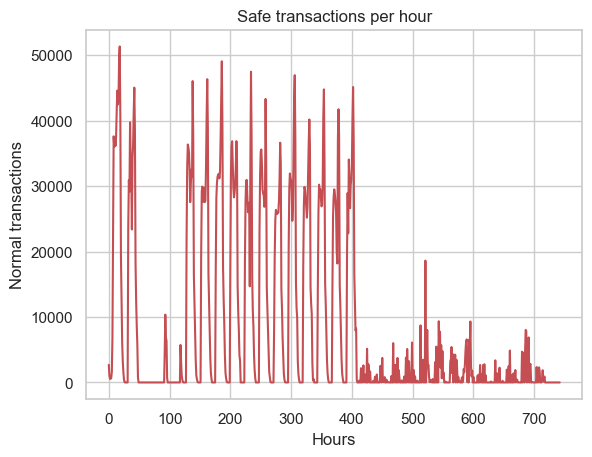

In [18]:
plt.plot(l4, color = "r" )
plt.title("Safe transactions per hour")
plt.xlabel("Hours")
plt.ylabel("Normal transactions")

Day wise separation of the data

In [21]:
def get_day_data(df):
    day = []
    val = 1
    for i in df["hour"]:
        day.append(val)
        if i % 24 == 0:
            val += 1
    return day

day = get_day_data(fraud_tx_per_hour)

fraud_tx_per_hour["day"] = day
fraud_tx_per_hour

,hour,total_tx,fraud_tx,valid_tx,day
0,1,2708,16,2692,1
1,2,1014,8,1006,1
2,3,552,4,548,1
3,4,565,10,555,1
4,5,665,6,659,1
...,...,...,...,...,...
738,739,10,10,0,31
739,740,6,6,0,31
740,741,22,22,0,31
741,742,14,14,0,31


In [ ]:
def plot_tx_day(df, day_num):
    fig, axes = plt.subplots(3, 1, figsize = (10,20))
    axes[0].set_title(f"day - {day_num}")
    sns.barplot(x = "hour", y = "total_tx", data = df, ax = axes[0])
    sns.barplot(x = "hour", y = "fraud_tx", data = df, ax = axes[1])
    sns.barplot(x = "hour", y = "valid_tx", data = df, ax = axes[2])

d1 = fraud_tx_per_hour.loc[fraud_tx_per_hour["day"] == 1] #Set the graphs for the first day
plot_tx_day(d1, 1)

# For every day

for day in range(1, 32):
    day_df = fraud_tx_per_hour[fraud_tx_per_hour["day"] == day]
    plot_tx_day(df, day_df)

### **Insight**

During the following days:

(1, 3, 6, 7 ,8 ,9, 10)

Most of the fraud transactions happened during early hours of that thay or duirng late hours

on days 2 and 5 the tendency broke and there were more fraudulent transactiosn during the mid day

for the non fraudulent transactions:

mid day to late hours maximum valid transation takes place so a constant pattern is observed [between 11-21 hours]

### **Hour wise plot**

In [25]:
fraud_Transactions = df.loc[df.isFraud == 1].type.drop_duplicates().values
print(list(fraud_Transactions))

['TRANSFER', 'CASH_OUT']


In [30]:
dfTransactions = df.loc[(df.type == "TRANSFER" )| (df.type == "CASH_OUT")]
dfFraud = dfTransactions["isFraud"]
del dfTransactions["isFraud"]

In [31]:
dfFraud.head()

2     1
3     1
15    0
19    0
24    0
Name: isFraud, dtype: int64

In [32]:
dfTransactions.dtypes

step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFlaggedFraud      int64
dtype: object

In [33]:
dfTransactions["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

In [35]:
# Primero convierte la columna a object para aceptar mixed types
dfTransactions["type"] = dfTransactions["type"].astype(object)

# Luego reemplaza
dfTransactions.loc[dfTransactions["type"] == "TRANSFER", "type"] = 0
dfTransactions.loc[dfTransactions["type"] == "CASH_OUT", "type"] = 1

# Finalmente convierte solo las filas que son 0 o 1
dfTransactions["type"] = pd.to_numeric(dfTransactions["type"], errors="coerce")

In [36]:
dfTransactions.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud
2,1,0,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,0
3,1,1,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,0
15,1,1,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0
19,1,0,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0
24,1,0,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0


In [37]:
dfTransactions_fraud = dfTransactions.loc[dfFraud == 1]
dfTransactions_non_fraud = dfTransactions.loc[dfFraud == 0]

fraction_anomaly_tx_in_fraud = len(dfTransactions_fraud.loc[
    (dfTransactions_fraud.oldbalanceDest == 0)
    & (dfTransactions_fraud.newbalanceDest == 0)
    & (dfTransactions_fraud.amount)
]) / (1.0 * len(dfTransactions_fraud))

print("Part of the anomaly trasnactions among fraudulent: ",
      fraction_anomaly_tx_in_fraud)

fraction_anomaly_tx_non_fraud = len(dfTransactions_non_fraud.loc[
    (dfTransactions_non_fraud.oldbalanceDest == 0)
    & (dfTransactions_non_fraud.newbalanceDest == 0)
    & (dfTransactions_non_fraud.amount)
]) / (1.0 * len(dfTransactions_non_fraud))

print("Part of anomaly Transactions among regular (non-fraudulent): ",
      fraction_anomaly_tx_non_fraud)

Part of the anomaly trasnactions among fraudulent:  0.4955558261293072
Part of anomaly Transactions among regular (non-fraudulent):  0.0006176245277308345


In [38]:
dfTransactions.loc[
                   (dfTransactions.oldbalanceDest == 0) 
                   & (dfTransactions.newbalanceDest == 0) 
                   & (dfTransactions.amount != 0),  
                   ['oldbalanceDest', 'newbalanceDest']] = - 1

In [39]:
dfTransactions.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud
6362615,743,1,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,0
6362616,743,0,6311409.28,C1529008245,6311409.28,0.0,C1881841831,-1.00,-1.00,0
6362617,743,1,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,0
6362618,743,0,850002.52,C1685995037,850002.52,0.0,C2080388513,-1.00,-1.00,0
6362619,743,1,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,0


In [40]:
dfTransactions.loc[ 
                   (dfTransactions.oldbalanceOrg == 0)
                   & (dfTransactions.newbalanceOrig == 0) & (dfTransactions.amount != 0), 
                   ['oldbalanceOrg', 'newbalanceOrig']] = np.nan

In [41]:
dfTransactions.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud
2,1,0,181.00,C1305486145,181.0,0.0,C553264065,-1.0,-1.00,0
3,1,1,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,0
15,1,1,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0
19,1,0,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0
24,1,0,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0


In [42]:
dfTransactions['errorbalanceDest'] = dfTransactions.oldbalanceDest + dfTransactions.amount - dfTransactions.newbalanceDest
dfTransactions['errorbalanceOrig'] = dfTransactions.newbalanceOrig + dfTransactions.amount - dfTransactions.oldbalanceOrg

In [43]:
dfTransactions.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud,errorbalanceDest,errorbalanceOrig
2,1,0,181.00,C1305486145,181.0,0.0,C553264065,-1.0,-1.00,0,181.0,0.00
3,1,1,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,0,21363.0,0.00
15,1,1,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,182703.5,213808.94
19,1,0,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,237735.3,214605.30
24,1,0,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,-2401220.0,300850.89


In [44]:
list(dfTransactions)

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFlaggedFraud',
 'errorbalanceDest',
 'errorbalanceOrig']

model characteristics

In [45]:
dfTransactions = dfTransactions.drop( [ "nameOrig", "nameDest", "isFlaggedFraud"], axis = 1)

In [46]:
dfTransactions.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorbalanceDest,errorbalanceOrig
2,1,0,181.00,181.0,0.0,-1.0,-1.00,181.0,0.00
3,1,1,181.00,181.0,0.0,21182.0,0.00,21363.0,0.00
15,1,1,229133.94,15325.0,0.0,5083.0,51513.44,182703.5,213808.94
19,1,0,215310.30,705.0,0.0,22425.0,0.00,237735.3,214605.30
24,1,0,311685.89,10835.0,0.0,6267.0,2719172.89,-2401220.0,300850.89


In [47]:
list(dfTransactions)

['step',
 'type',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'errorbalanceDest',
 'errorbalanceOrig']

Model Training

In [50]:
randomState = 5
np.random.seed(randomState)

# Divide train / test split
Xtrain, Xtest, ytrain, ytest = train_test_split(dfTransactions, dfFraud, test_size= 0.2, random_state= randomState )

In [52]:
weights = (dfFraud == 0).sum() / (1.0 * (dfFraud == 1).sum())

# Implement XGBoost random forest classifier

classifier = XGBClassifier(max_depth = 3, scale_pos_weight = weights, n_jobs = 4)
predictions = classifier.fit(Xtrain, ytrain).predict_proba(Xtest)

Model validation

In [53]:
from sklearn.metrics import average_precision_score

AURPC = average_precision_score(ytest, predictions[:, 1])
AURPC

0.9926360768575738

In [54]:
preddf = classifier.predict(Xtest)

In [55]:
preddf

array([0, 0, 0, ..., 0, 0, 0], shape=(554082,))

In [56]:
from sklearn.metrics import classification_report

print(classification_report(ytest, preddf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552412
           1       0.85      1.00      0.92      1670

    accuracy                           1.00    554082
   macro avg       0.92      1.00      0.96    554082
weighted avg       1.00      1.00      1.00    554082



validation row for backtesting

In [57]:
onerow = pd.DataFrame({'step': [459], 'type': [0], 'amount': [1153156], 'oldbalanceOrg': [1153156]
                       , 'newbalanceOrig': [0], 'oldbalanceDest': [-1], 'newbalanceDest': [-1], 'errorbalanceDest': [1153156]
                       , 'errorbalanceOrig': [0]})

In [58]:
onerow

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorbalanceDest,errorbalanceOrig
0,459,0,1153156,1153156,0,-1,-1,1153156,0


In [59]:
predictions

array([[9.9993008e-01, 6.9944566e-05],
       [9.9996501e-01, 3.4965320e-05],
       [9.9988854e-01, 1.1146458e-04],
       ...,
       [9.9998248e-01, 1.7526678e-05],
       [9.9999857e-01, 1.4333785e-06],
       [9.9999899e-01, 9.8503631e-07]], shape=(554082, 2), dtype=float32)

In [60]:
Xtest[Xtest.index == 6020168]

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorbalanceDest,errorbalanceOrig
6020168,459,0,1153156.0,1153156.0,0.0,-1.0,-1.0,1153156.0,0.0


In [61]:
ytest[ytest == 1]

6272989    1
1640528    1
6020168    1
6318843    1
1511381    1
          ..
5248384    1
3594476    1
6259942    1
819544     1
4388729    1
Name: isFraud, Length: 1670, dtype: int64

In [63]:
Xtest.shape

(554082, 9)

In [64]:
print(Xtest.iloc[0])

step                    205.00
type                      1.00
amount                63243.44
oldbalanceOrg              NaN
newbalanceOrig             NaN
oldbalanceDest      1853683.32
newbalanceDest      1916926.76
errorbalanceDest          0.00
errorbalanceOrig           NaN
Name: 2537487, dtype: float64


In [66]:
Xtest.isnull().sum()

step                     0
type                     0
amount                   0
oldbalanceOrg       261654
newbalanceOrig      261654
oldbalanceDest           0
newbalanceDest           0
errorbalanceDest         0
errorbalanceOrig    261654
dtype: int64

In [ ]:
classifier.save_model()

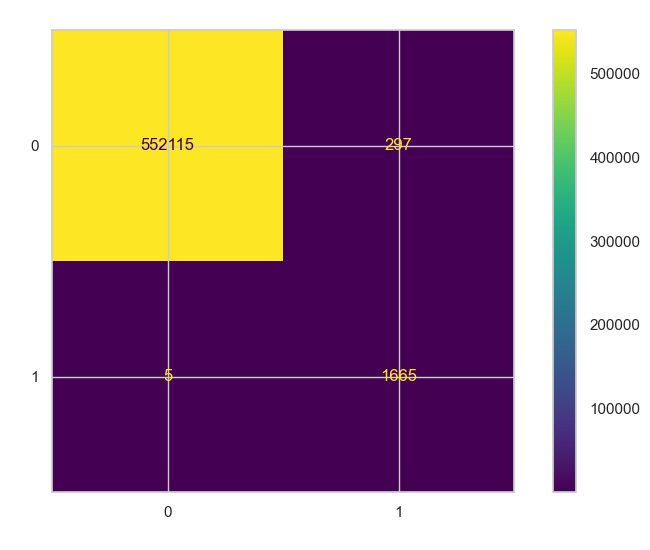

In [70]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(ytest, classifier.predict(Xtest))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
disp.ax_.set_title('Confusion Matrix', color='white')
plt.xlabel('Predicted label', color='white')
plt.ylabel('True label', color='white')
plt.gcf().axes[0].tick_params(color='white')
plt.gcf().axes[1].tick_params(color='white')
plt.gcf().set_size_inches(10, 6)
plt.show()

AUCROC plot

In [71]:
# Prediction probabilities

from sklearn.metrics import roc_curve, roc_auc_score

classifier_probs = classifier.predict_proba(Xtest)
classifier_probs = classifier_probs[:,1]

In [72]:
# Print auroc scores
classifier_auc = roc_auc_score(ytest, classifier_probs)

In [75]:
# calculate roc curve
classifier_fpr, classifier_tpr,_ = roc_curve(ytest, classifier_probs) 

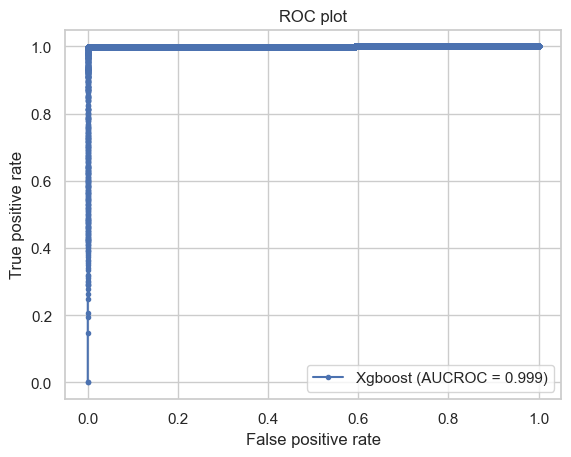

In [76]:
plt.plot(classifier_fpr, classifier_tpr, marker = '.', label = 'Xgboost (AUCROC = %0.3f)'%classifier_auc)
plt.title("ROC plot")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()

In [86]:
def detect_outliers(dfTransactions):
    threshold = 3
    outliers = []
    numeric_df = dfTransactions.select_dtypes(include=["float64", "int64"])
    
    for col in numeric_df.columns:
        mean = np.mean(numeric_df[col])
        std = np.std(numeric_df[col])
        for i, val in enumerate(numeric_df[col]):
            z_score = (val - mean) / std
            if np.abs(z_score) > threshold:
                outliers.append(i)
    return outliers

In [87]:
outlier_pt=detect_outliers(dfTransactions)
len(outlier_pt)

154658

### **save the model for a next stramlit deploy**

In [89]:
classifier.save_model("fraud_xgbmodel.json")

# **NOTE**

Current model was taken from Kaggle's dataset:

https://github.com/Bella-ciaoo/BerTrugS/tree/main?tab=readme-ov-file

This notebook was for validation and learning purpose 